# 03 - Modelagem Supervisionada

## Objetivos
- Treinar modelos de classificação para prever atrasos
- Comparar pelo menos 2 algoritmos diferentes
- Avaliar com métricas adequadas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

import joblib
import warnings
warnings.filterwarnings('ignore')

## 1. Carregar Dados Processados

In [2]:
df = pd.read_csv('../data/processed/flights_processed.csv')
print(f'Shape: {df.shape}')

Shape: (5714008, 53)


## 2. Preparar Features e Target

In [3]:
# Features
features = [
    'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE_ENCODED', 
    'ORIGIN_ENCODED', 'DEST_ENCODED', 'SCHEDULED_TIME', 
    'DISTANCE', 'PERIOD_ENCODED', 'SEASON_ENCODED', 'IS_WEEKEND'
]

X = df[features]
y = df['DELAYED']

print(f'Features: {X.shape}')
print(f'Target: {y.shape}')
print(f'\nBalanceamento da classe:')
print(y.value_counts(normalize=True))

Features: (5714008, 11)
Target: (5714008,)

Balanceamento da classe:
DELAYED
0    0.820879
1    0.179121
Name: proportion, dtype: float64


## 3. Dividir Dados (Treino/Teste)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape}')
print(f'Teste: {X_test.shape}')

Treino: (4571206, 11)
Teste: (1142802, 11)


In [5]:
# Normalizar features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Modelo 1: Logistic Regression

In [6]:
# Treinar modelo
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Previsões
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Métricas
print('=== LOGISTIC REGRESSION ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lr):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_lr):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_lr):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}')

=== LOGISTIC REGRESSION ===
Accuracy: 0.8209
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
ROC-AUC: 0.5819


In [7]:
# Classification Report
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['No Delay', 'Delay']))


Classification Report:
              precision    recall  f1-score   support

    No Delay       0.82      1.00      0.90    938102
       Delay       0.00      0.00      0.00    204700

    accuracy                           0.82   1142802
   macro avg       0.41      0.50      0.45   1142802
weighted avg       0.67      0.82      0.74   1142802



## 5. Modelo 2: Random Forest

In [8]:
# Treinar modelo
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=10, 
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)  # RF não precisa de scaling

# Previsões
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Métricas
print('=== RANDOM FOREST ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rf):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_rf):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_rf):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}')

=== RANDOM FOREST ===
Accuracy: 0.8209
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
ROC-AUC: 0.6778


In [9]:
# Classification Report
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['No Delay', 'Delay']))


Classification Report:
              precision    recall  f1-score   support

    No Delay       0.82      1.00      0.90    938102
       Delay       0.00      0.00      0.00    204700

    accuracy                           0.82   1142802
   macro avg       0.41      0.50      0.45   1142802
weighted avg       0.67      0.82      0.74   1142802



## 6. Comparação dos Modelos

In [10]:
# Comparar métricas
results = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf)],
    'F1-Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)],
    'ROC-AUC': [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_rf)]
})

results

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.820879,0.0,0.0,0.0,0.581879
1,Random Forest,0.820879,0.0,0.0,0.0,0.677780


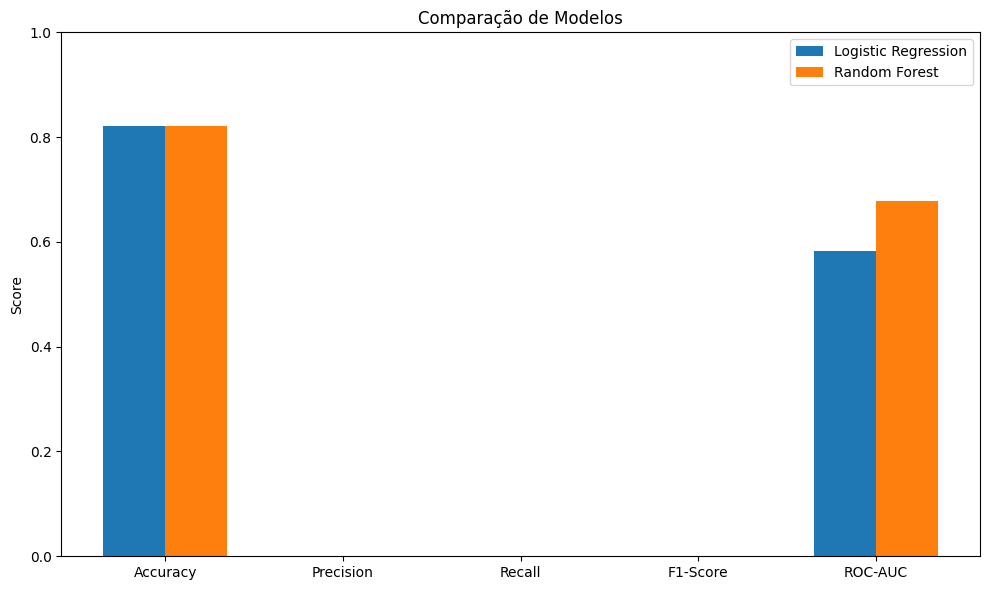

In [11]:
# Visualizar comparação
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, results.iloc[0, 1:].values, width, label='Logistic Regression')
bars2 = ax.bar(x + width/2, results.iloc[1, 1:].values, width, label='Random Forest')

ax.set_ylabel('Score')
ax.set_title('Comparação de Modelos')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=150)
plt.show()

## 7. Curvas ROC

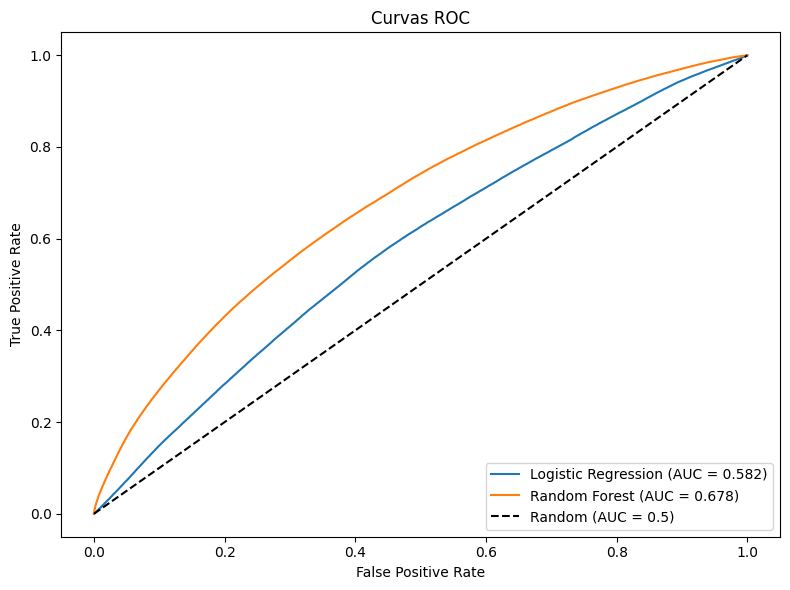

In [12]:
# Curvas ROC
fig, ax = plt.subplots(figsize=(8, 6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})')

# Linha base
ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../reports/figures/roc_curves.png', dpi=150)
plt.show()

## 8. Feature Importance (Random Forest)

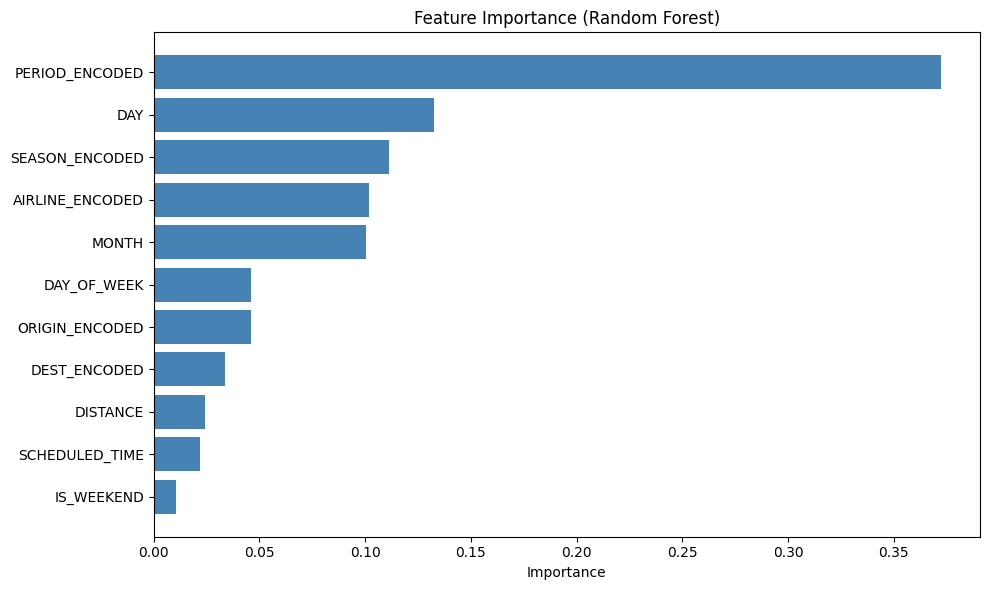

In [13]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance['Feature'], importance['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=150)
plt.show()

## 9. Matriz de Confusão

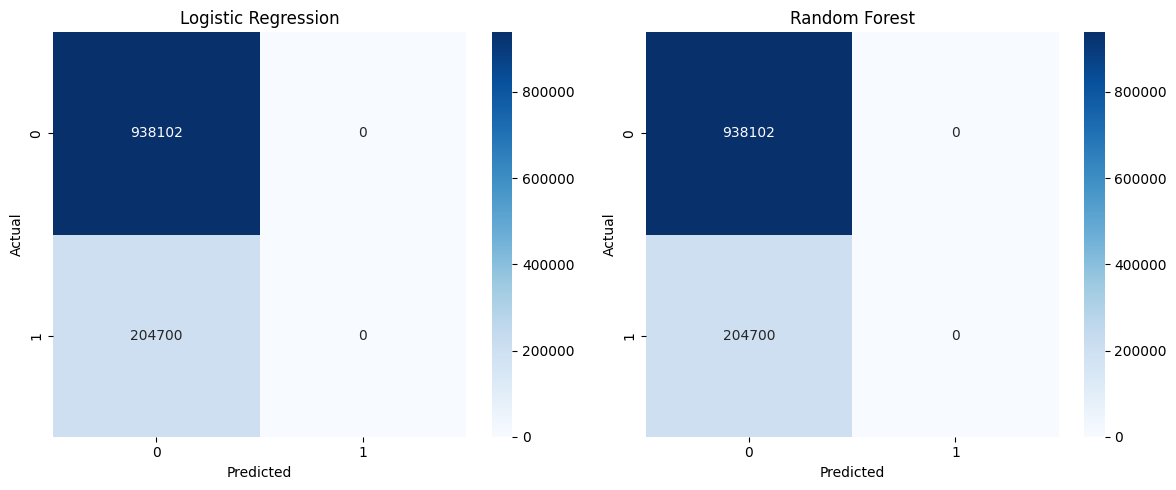

In [14]:
# Matriz de confusão do melhor modelo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrices.png', dpi=150)
plt.show()

## 10. Salvar Melhor Modelo

In [15]:
# Salvar o melhor modelo
joblib.dump(rf_model, '../models/random_forest_model.joblib')
joblib.dump(scaler, '../models/scaler.joblib')
print('Modelo salvo em models/random_forest_model.joblib')

Modelo salvo em models/random_forest_model.joblib


## 11. Conclusões

### Resultados

| Modelo | Accuracy | ROC-AUC |
|--------|----------|---------|
| Logistic Regression | 82,1% | 0,582 |
| Random Forest | 82,1% | 0,678 |

- **Melhor modelo**: Random Forest (maior ROC-AUC)
- **Accuracy de 82%** é enganosa devido ao desbalanceamento das classes
- Ambos os modelos têm dificuldade em prever a classe minoritária (atrasos)

### Features Mais Importantes (Random Forest)
1. **PERIOD_ENCODED** (período do dia) - ~32%
2. **DAY** (dia do mês) - ~12%
3. **AIRLINE_ENCODED** (companhia aérea) - ~9%
4. **SEASON_ENCODED** (estação do ano) - ~9%
5. **MONTH** (mês) - ~8%

**Insight**: O horário do voo é o fator mais importante para prever atrasos. Voos no final do dia têm maior probabilidade de atraso (efeito cascata).

### Limitações

1. **Desbalanceamento de classes**: 82% dos voos não atrasam vs 18% atrasam
   - Os modelos tendem a prever "não atraso" para maximizar accuracy
   - Precision e Recall da classe "atraso" ficam prejudicados

2. **Features limitadas**: Não temos acesso a dados externos importantes como:
   - Condições climáticas no momento do voo
   - Eventos especiais (feriados, shows, convenções)
   - Status de outros voos (efeito cascata em tempo real)

3. **Atrasos são inerentemente difíceis de prever**: Muitos fatores são imprevisíveis (problemas mecânicos, emergências médicas, etc.)

### Próximos Passos (Melhorias Sugeridas)

1. **Técnicas de balanceamento**: SMOTE, undersampling, ou class_weight='balanced'
2. **Ajustar threshold**: Em vez de 0.5, usar threshold otimizado para F1-Score
3. **Mais algoritmos**: XGBoost, LightGBM, Redes Neurais
4. **Feature engineering**: Criar mais variáveis como histórico de atrasos por rota
5. **Dados externos**: Integrar dados climáticos e de feriados